In [72]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

print(pd.__version__)
#print(plt.__version__)
print(sns.__version__)
print(np.__version__)

3.0.0
0.13.2
2.3.2


In [73]:
df = pd.read_csv('../Datasets/Housing.csv')

In [74]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Train Split


In [75]:
from sklearn.model_selection import train_test_split

In [76]:
X = df.drop('price', axis=1)
y = df['price']

In [77]:
y = np.log1p(y)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [79]:
print("X_train Shape:",  X_train.shape)
print("X_test Shape:", X_test.shape)
print("Y_train Shape:", y_train.shape)
print("Y_test Shape:", y_test.shape)

X_train Shape: (381, 12)
X_test Shape: (164, 12)
Y_train Shape: (381,)
Y_test Shape: (164,)


# Encoder

In [80]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Features:", numeric_features)

categorical_features = X_train.select_dtypes(include=['str']).columns
print("Categorical Features:", categorical_features)

Numeric Features: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')
Categorical Features: Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [81]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder

scaler = RobustScaler()
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

numeric_scaled = scaler.fit_transform(X_train[numeric_features])
numeric_scaled_test = scaler.transform(X_test[numeric_features])
categorical_encoded = encoder.fit_transform(X_train[categorical_features])
categorical_encoded_test = encoder.transform(X_test[categorical_features])

print("Numeric Scaled Shape:", numeric_scaled.shape)
print("Numeric Scaled Test Shape:", numeric_scaled_test.shape)
print("Categorical Encoded Shape:", categorical_encoded.shape)
print("Categorical Encoded Test Shape:", categorical_encoded_test.shape)


Numeric Scaled Shape: (381, 5)
Numeric Scaled Test Shape: (164, 5)
Categorical Encoded Shape: (381, 8)
Categorical Encoded Test Shape: (164, 8)


In [82]:
# concatenate numeric and categorical features
X_train_processed = np.concatenate((numeric_scaled, categorical_encoded), axis=1)
X_test_processed = np.concatenate((numeric_scaled_test, categorical_encoded_test), axis=1)

print("X_train Processed Shape:", X_train_processed.shape)
print("X_test Processed Shape:", X_test_processed.shape)

X_train Processed Shape: (381, 13)
X_test Processed Shape: (164, 13)


Improvement, use Column transformer instead:

https://www.geeksforgeeks.org/machine-learning/using-columntransformer-in-scikit-learn-for-data-preprocessing/

# Models

Guide: https://www.geeksforgeeks.org/machine-learning/implementation-of-lasso-ridge-and-elastic-net/

## Ridge

In [83]:
from sklearn.linear_model import Ridge

Ridge_model  = Ridge(alpha = 10)
Ridge_model.fit(X_train_processed, y_train)
y_pred_Ridge = Ridge_model.predict(X_test_processed)

In [84]:
y_pred_Ridge_real = np.expm1(y_pred_Ridge)   

In [85]:
# ONly do this once:
y_test_real = np.expm1(y_test) 

In [86]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_Ridge_real[:10]])
print('Real prices: \n', [int(i) for i in y_test_real[:10]])        

First 10:
Predicted prices: 
 [5823556, 6037299, 6453882, 5173396, 4228235, 3227200, 2826192, 7395776, 2711938, 4381409]
Real prices: 
 [7069999, 4550000, 5599999, 6124999, 2939999, 3780000, 2449999, 7490000, 2939999, 6440000]


In [87]:
# Example prediction
new_house = pd.DataFrame([{'area': 5000, 'bedrooms': 3, 'bathrooms': 2,
'stories': 2,'parking':1, 'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
'hotwaterheating': 'no', 'airconditioning': 'yes',
'prefarea': 'no', 'furnishingstatus': 'semi-furnished'}])

# Apply the same preprocessing pipeline to the new house data
new_house_numeric_scaled = scaler.transform(new_house[numeric_features])
new_house_categorical_encoded = encoder.transform(new_house[categorical_features])

new_house_processed = np.concatenate((new_house_numeric_scaled, new_house_categorical_encoded), axis=1)

predicted_price = Ridge_model.predict(new_house_processed)
predicted_price = np.expm1(predicted_price) # reverse log scale
print(predicted_price)

[5439438.42291617]


Almost same predictions as Linear Regression

In [143]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, model_name="Model"):
    r2  = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"R-squared:              {r2:.4f}")
    print(f"Mean Squared Error:     {mse:.4f}")
    print(f"Root Mean Sq Error:     {np.sqrt(mse):.4f}")
    print(f"Mean Absolute Error:    {mae:.4f}")
    print()

In [145]:
evaluate_model(y_test_real, y_pred_Ridge_real, "Ridge")

--- Ridge ---
R-squared:              0.6828
Mean Squared Error:     1291075670458.1921
Root Mean Sq Error:     1136255.1080
Mean Absolute Error:    816449.8542



In [91]:
ridge_df = pd.DataFrame({})
ridge_coefficients = Ridge_model.coef_
ridge_df['Coefficients'] = ridge_coefficients
ridge_df['Feature'] = list(numeric_features) + list(encoder.get_feature_names_out(categorical_features))
ridge_df_sorted = ridge_df.sort_values(by = 'Coefficients', ascending = False)

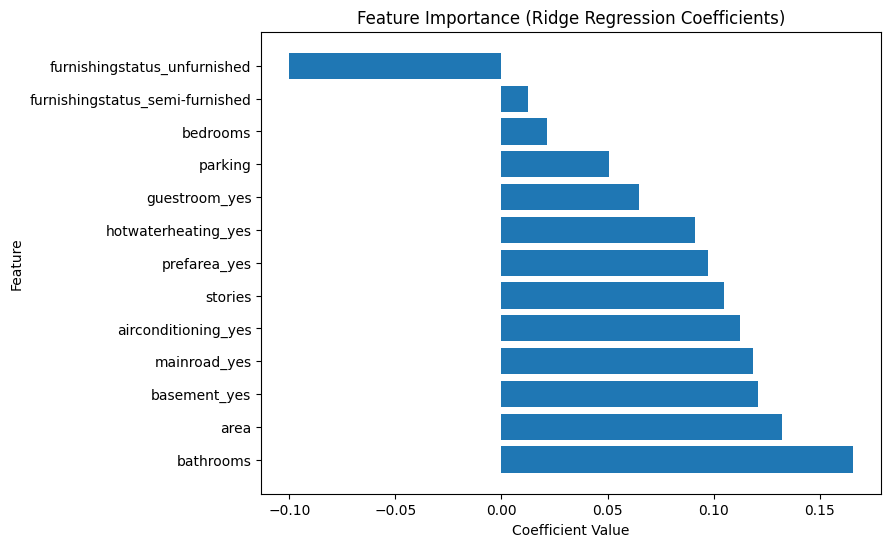

In [92]:

plt.figure(figsize=(8,6))
plt.barh(ridge_df_sorted["Feature"], ridge_df_sorted["Coefficients"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Ridge Regression Coefficients)")
plt.show()

## Lasso

In [96]:
from sklearn.linear_model import Lasso

Lasso_model = Lasso(alpha = 0.01)
Lasso_model.fit(X_train_processed, y_train)
y_pred_Lasso = Lasso_model.predict(X_test_processed)

In [97]:
y_pred_Lasso_real = np.expm1(y_pred_Lasso)   

In [98]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_Lasso_real[:10]])
print('Real prices: \n', [int(i) for i in y_test_real[:10]])        

First 10:
Predicted prices: 
 [5733583, 6267152, 6526429, 5236439, 4301347, 3284551, 2937181, 7211904, 2909022, 4315043]
Real prices: 
 [7069999, 4550000, 5599999, 6124999, 2939999, 3780000, 2449999, 7490000, 2939999, 6440000]


In [99]:
predicted_price = Lasso_model.predict(new_house_processed)
predicted_price = np.expm1(predicted_price) # reverse log scale
print(predicted_price)

[5328344.6948368]


In [146]:
evaluate_model(y_test_real, y_pred_Lasso_real,"Lasso")

--- Lasso ---
R-squared:              0.6419
Mean Squared Error:     1457594434523.5117
Root Mean Sq Error:     1207308.7569
Mean Absolute Error:    850015.0271



In [104]:
Lasso_df = pd.DataFrame({})
Lasso_coefficients = Lasso_model.coef_
Lasso_df['Coefficients'] = Lasso_coefficients
Lasso_df['Feature'] = list(numeric_features) + list(encoder.get_feature_names_out(categorical_features))
Lasso_df_sorted = Lasso_df.sort_values(by = 'Coefficients', ascending = False)

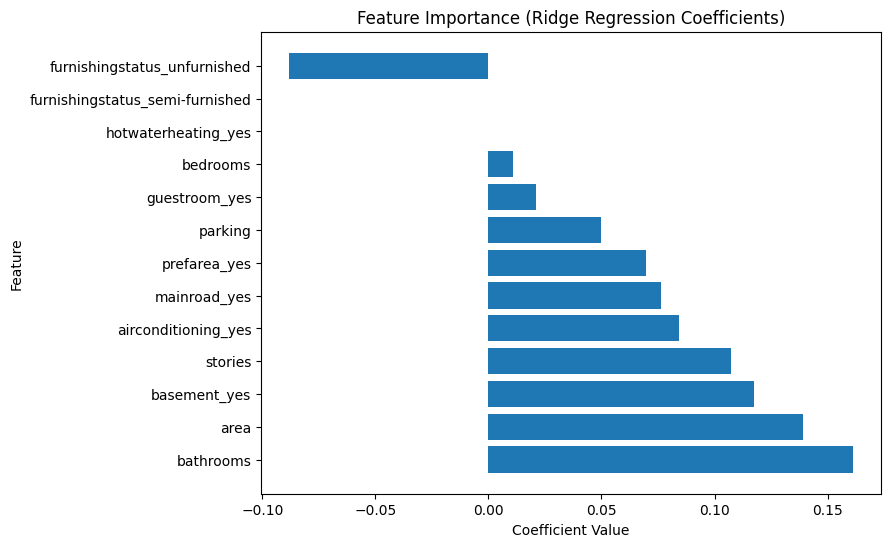

In [105]:

plt.figure(figsize=(8,6))
plt.barh(Lasso_df_sorted["Feature"], Lasso_df_sorted["Coefficients"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Ridge Regression Coefficients)")
plt.show()

## Elastic Net

In [112]:
from sklearn.linear_model import ElasticNet

ENet = ElasticNet(alpha = 0.1)
ENet.fit(X_train_processed, y_train)
y_pred_ENet = ENet.predict(X_test_processed)

In [113]:
y_pred_ENet_real = np.expm1(y_pred_ENet)

In [114]:
print("First 10:")
print('Predicted prices: \n', [int(i) for i in y_pred_ENet_real[:10]])
print('Real prices: \n', [int(i) for i in y_test_real[:10]])        

First 10:
Predicted prices: 
 [5061905, 6591765, 6123922, 4924577, 4610188, 3717354, 3810588, 6047068, 3570744, 4289044]
Real prices: 
 [7069999, 4550000, 5599999, 6124999, 2939999, 3780000, 2449999, 7490000, 2939999, 6440000]


In [115]:
predicted_price = ENet.predict(new_house_processed)
predicted_price = np.expm1(predicted_price) # reverse log scale
print(predicted_price)

[4761355.46253839]


 try the metrics for training as well 

In [147]:
evaluate_model(y_test_real, y_pred_ENet_real,"ElasticNet")

--- ElasticNet ---
R-squared:              0.3792
Mean Squared Error:     2527068274272.0298
Root Mean Sq Error:     1589675.5248
Mean Absolute Error:    1115419.1878



In [121]:
ENet_df = pd.DataFrame({})
ENet_coefficients = ENet.coef_
ENet_df['Coefficients'] = ENet_coefficients
ENet_df['Feature'] = list(numeric_features) + list(encoder.get_feature_names_out(categorical_features))
ENet_df_sorted = ENet_df.sort_values(by = 'Coefficients', ascending = False)

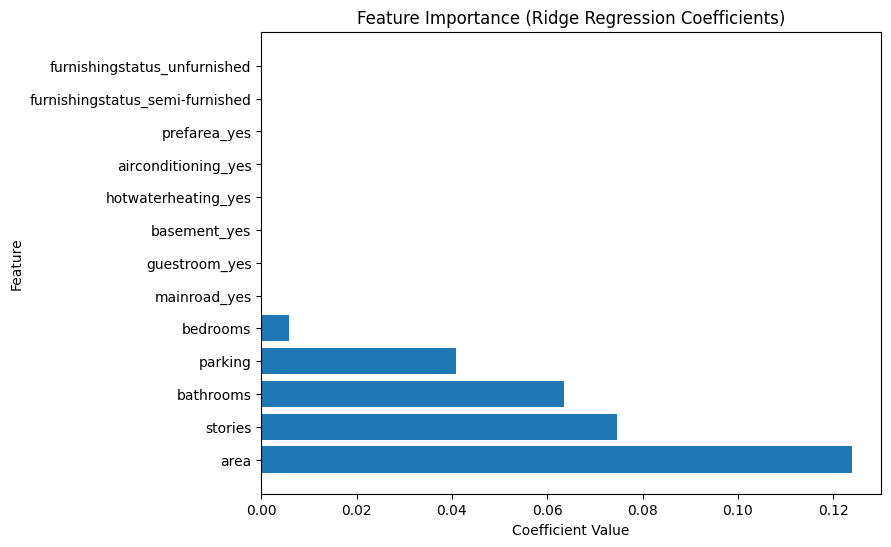

In [122]:
plt.figure(figsize=(8,6))
plt.barh(ENet_df_sorted["Feature"], ENet_df_sorted["Coefficients"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Ridge Regression Coefficients)")
plt.show()

# Hyperparameter Tuning

In [125]:
from sklearn.model_selection import GridSearchCV

param_R_L = {
    'alpha' : [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

param_ENet = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

## Ridge

In [126]:
grid_search_Ridge = GridSearchCV(Ridge_model, param_R_L, cv=5)
grid_search_Ridge.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge(alpha=10)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexe

In [148]:
# Print the best hyperparameters found by each method
Best_Ridge_model = grid_search_Ridge.best_estimator_
print(f"Best hyperparameters found by GridSearchCV: {Best_Ridge_model}")

Best hyperparameters found by GridSearchCV: Ridge(alpha=1)


In [ ]:
y_test_Best_Ridge_model = Best_Ridge_model.predict(X_test_processed)
y_test_Best_Ridge_real = np.expm1(y_test_Best_Ridge_model)

In [150]:
evaluate_model(y_test_real, y_test_Best_Ridge_real, "Ridge (Tuned)")

--- Ridge (Tuned) ---
R-squared:              0.6902
Mean Squared Error:     1260931076465.2346
Root Mean Sq Error:     1122911.8739
Mean Absolute Error:    812754.0048



## Lasso

In [128]:
grid_search_Lasso = GridSearchCV(Lasso_model, param_R_L, cv=5)
grid_search_Lasso.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(alpha=0.01)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

In [153]:
Best_Lasso_model = grid_search_Lasso.best_estimator_
print(f"Best hyperparameters found by GridSearchCV: {Best_Lasso_model}")

Best hyperparameters found by GridSearchCV: Lasso(alpha=0.0001)


In [154]:
y_test_Best_Lasso_model = Best_Lasso_model.predict(X_test_processed)
y_test_Best_Lasso_real = np.expm1(y_test_Best_Lasso_model)

In [155]:
evaluate_model(y_test_real, y_test_Best_Lasso_real, "Lasso (Tuned)")

--- Lasso (Tuned) ---
R-squared:              0.6906
Mean Squared Error:     1259199191661.7366
Root Mean Sq Error:     1122140.4510
Mean Absolute Error:    813209.9692



## Elastic Net

In [130]:
grid_search_ENet = GridSearchCV(ENet, param_ENet, cv=5)
grid_search_ENet.fit(X_train_processed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet(alpha=0.1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...], 'l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [137]:
# Print the best hyperparameters found by each method
Best_ENet = grid_search_ENet.best_estimator_
print(f"Best hyperparameters found by GridSearchCV: {Best_ENet}")

Best hyperparameters found by GridSearchCV: ElasticNet(alpha=0.001, l1_ratio=0.3)


In [157]:
y_test_Best_ENet = Best_ENet.predict(X_test_processed)
y_test_Best_ENet_real = np.expm1(y_test_Best_ENet)

In [158]:
evaluate_model(y_test_real, y_test_Best_ENet_real, "Lasso (Tuned)")

--- Lasso (Tuned) ---
R-squared:              0.6899
Mean Squared Error:     1262246878733.1370
Root Mean Sq Error:     1123497.6096
Mean Absolute Error:    812896.1833

